# 3. Data Cleansing and Transformation

## 3.1 Data Cleaning and Preparation


In [1]:
import pandas as pd

df = pd.read_csv("../data/patient_data.csv")
df_original = df.copy(deep=True)

In [2]:
# Define the data cleaning function
def clean_data(data):
    clean = data.copy(deep=True)

    # Create the binary heart disease target from sublabel
    heart_disease_labels = ["HT", "DI_HT", "HT_HY", "DI_HT_HY"]
    clean["heart_disease_target"] = clean["sublabel"].isin(heart_disease_labels)

    # Remove duplicate rows
    clean = clean.drop_duplicates()

    # Reset the index after cleaning
    clean = clean.reset_index(drop=True)

    return clean

In [3]:
# Apply the cleaning function
df_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df_original) - len(df_clean))

Original shape: (280985, 39)
Cleaned shape: (278701, 40)
Rows removed: 2284


In [4]:
print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nHeart disease target distribution:")
print(df_clean["heart_disease_target"].value_counts())

print("\nTarget mapping:")
print(
    pd.crosstab(
        df_clean["sublabel"],
        df_clean["heart_disease_target"]
    )
)


Duplicate rows:
0

Heart disease target distribution:
heart_disease_target
False    272810
True       5891
Name: count, dtype: int64

Target mapping:
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0


In [5]:
# Inspect disease related variables before deciding whether they should be retained
disease_related_columns = [
    "sublabel",
    "disease_flags",
    "label",
    "heart_disease",
    "diabetes",
    "hypertension"
]

for column in disease_related_columns:
    print(f"\n{column}")
    print(pd.crosstab(df_clean[column], df_clean["heart_disease_target"]))


sublabel
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0

disease_flags
heart_disease_target   False  True 
disease_flags                      
0,0,0                 104648      0
0,0,1                  69787      0
0,1,0                      0   2583
0,1,1                      0   1065
1,0,0                  31903      0
1,0,1                  66472      0
1,1,0                      0   1398
1,1,1                      0    845

label
heart_disease_target   False  True 
label                              
Abnormal              168162   5891
Normal                104648      0

heart_disease
heart_disease_target   False  True 
heart_disease                      
0.000000         

In [6]:
# Check the data types after cleaning
df_clean.dtypes

composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl     

In [7]:
# Check categorical values for formatting or inconsistent categories
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


composite_key
composite_key
Middle_Female_Overweight_Never_No      5600
Mature_Female_Overweight_Never_No      5415
Middle_Female_Obese_Never_No           5020
Mature_Female_Obese_Never_No           4986
Middle_Female_Normal_Never_No          4806
                                       ... 
Young_Female_Underweight_Current_No     184
Young_Female_Underweight_Never_Yes      176
Young_Male_Underweight_Former_Yes       175
Young_Male_Underweight_Current_Yes      161
Young_Female_Underweight_Former_Yes     147
Name: count, Length: 192, dtype: int64

age_level
age_level
Mature    87019
Middle    84478
Senior    69824
Young     37380
Name: count, dtype: int64

gender
gender
Female    147336
Male      131365
Name: count, dtype: int64

bmi_level
bmi_level
Obese          98377
Overweight     76897
Normal         70591
Underweight    32836
Name: count, dtype: int64

smoking
smoking
Never      125797
Former      80063
Current     72841
Name: count, dtype: int64

diabetes
diabetes
No     178083
Y

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\628714087.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include="object").columns


physical_activity
High        118360
Moderate     80318
Low          80023
Name: count, dtype: int64

family_history
family_history
No     156011
Yes    122690
Name: count, dtype: int64

stress_level
stress_level
High      100653
Medium     89145
Low        88903
Name: count, dtype: int64

low_hdl_cholesterol
low_hdl_cholesterol
No     224091
Yes     54610
Name: count, dtype: int64

high_ldl_cholesterol
high_ldl_cholesterol
Yes    145355
No     133346
Name: count, dtype: int64

high_blood_pressure
high_blood_pressure
Yes    141960
No     136741
Name: count, dtype: int64

sugar_consumption
sugar_consumption
Low       121999
Medium     87032
High       69670
Name: count, dtype: int64

education_level
education_level
Tertiary     104770
Secondary     87750
Primary       86181
Name: count, dtype: int64

employment_status
employment_status
Retired       95043
Unemployed    94690
Employed      88968
Name: count, dtype: int64

source_dataset
source_dataset
hypertension    174982
diabetes     

In [8]:
# Check numerical ranges after cleaning
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,278701.0,49.710381,21.682385,2.000000,32.000000,50.000000,68.000000,89.000000
age_normalized,278701.0,0.548395,0.249223,0.000000,0.344827,0.551724,0.758620,1.000000
bmi,278701.0,27.492328,7.068966,10.010000,22.010000,27.320000,32.700000,95.690000
hypertension,278701.0,0.129193,0.187602,0.000000,0.000000,0.071823,0.217063,1.000000
heart_disease,278701.0,0.073945,0.138504,0.000000,0.000000,0.007800,0.117647,1.000000
HbA1c_level,278701.0,5.951910,0.952495,3.500000,5.387500,5.800000,6.865766,9.000000
glucose,278701.0,135.267784,38.503495,70.000000,100.000000,137.000000,160.000000,300.000000
cholesterol,278701.0,224.027190,35.668600,150.000000,201.000000,225.000000,243.000000,300.000000
sleep_hours,278701.0,6.954743,1.432179,4.000000,6.196679,6.975185,7.700000,10.000000
triglycerides,278701.0,178.540442,67.344842,50.000000,128.000000,178.000000,241.750000,400.000000


In [9]:
# Inspect unusual age values
print(df_clean["age"].sort_values().head(20))

print("\nHighest BMI values:")
print(df_clean["bmi"].sort_values(ascending=False).head(20))

11860    2
11859    2
11858    2
46796    2
46795    2
46794    2
46793    2
46792    2
46791    2
46790    2
46789    2
46788    2
46787    2
46786    2
46785    2
46779    2
6916     2
6915     2
6909     2
6573     2
Name: age, dtype: int64

Highest BMI values:
54042    95.69
51824    95.22
53301    91.82
62841    88.76
69995    88.72
12015    87.70
57800    87.51
58143    83.74
46154    81.73
13786    79.48
13523    79.46
38519    75.78
25641    73.77
16583    72.89
58266    72.28
34899    72.21
91318    72.03
15193    71.55
15227    70.96
88503    69.66
Name: bmi, dtype: float64


In [10]:
# Inspect records with the minimum age
df_clean.loc[
    df_clean["age"] == df_clean["age"].min(),
    ["age", "age_level"]
].value_counts()

age  age_level
2    Young        1179
Name: count, dtype: int64

In [11]:
# Inspect the highest BMI records and their BMI categories
df_clean[
    ["bmi", "bmi_level"]
].sort_values(
    by="bmi",
    ascending=False
).head(20)

,bmi,bmi_level
54042,95.69,Obese
51824,95.22,Obese
53301,91.82,Obese
62841,88.76,Obese
69995,88.72,Obese
12015,87.70,Obese
57800,87.51,Obese
58143,83.74,Obese
46154,81.73,Obese
13786,79.48,Obese


## 3.2 Outlier Investigation and Treatment

In [12]:
# Define a function to flag potential outliers using the IQR method
def iqr_flag(series):
    # Calculate the first and third quartiles
    q1, q3 = series.quantile([0.25, 0.75])

    # Calculate the interquartile range
    iqr = q3 - q1

    # Flag values below or above the 1.5 × IQR boundaries
    return (
        (series < q1 - 1.5 * iqr)
        | (series > q3 + 1.5 * iqr)
    )

In [13]:
# Flag potential BMI outliers using the IQR method
bmi_flag = iqr_flag(df_clean["bmi"])

# Display the number of BMI values flagged as potential outliers
print("Number of BMI outliers:", bmi_flag.sum())

# Inspect the flagged records with relevant contextual variables
print(
    df_clean.loc[
        bmi_flag,
        ["age", "gender", "bmi", "bmi_level", "heart_disease_target"]
    ]
    .sort_values("bmi")
    .to_string()
)

Number of BMI outliers: 1005
       age  gender    bmi bmi_level  heart_disease_target
33499   50  Female  48.74     Obese                 False
58833   31  Female  48.75     Obese                 False
35926   22  Female  48.78     Obese                 False
92521   41    Male  48.78     Obese                 False
15865   38  Female  48.79     Obese                 False
7226    28  Female  48.80     Obese                 False
35155   54  Female  48.81     Obese                 False
92947   43    Male  48.81     Obese                 False
2941    29  Female  48.81     Obese                 False
89422   43    Male  48.82     Obese                 False
21250   47  Female  48.82     Obese                 False
80409   64    Male  48.82     Obese                  True
91397   42    Male  48.82     Obese                 False
76645   39    Male  48.82     Obese                 False
29886   56  Female  48.83     Obese                 False
10626   40  Female  48.83     Obese        

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\129251407.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


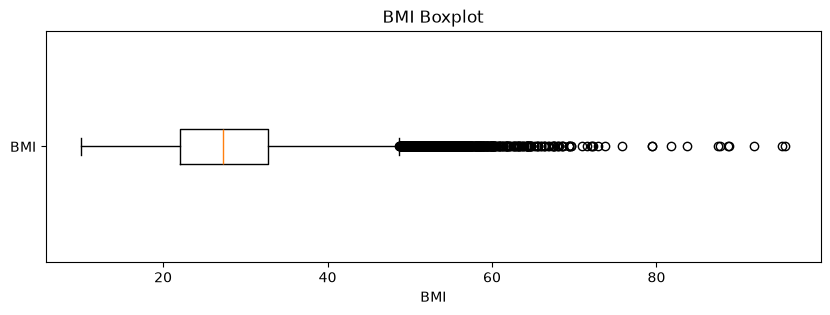

In [14]:
import matplotlib.pyplot as plt

# Create a boxplot to identify potential BMI outliers
plt.figure(figsize=(10, 3))

plt.boxplot(
    df_clean["bmi"].dropna(),
    vert=False,
    tick_labels=["BMI"]
)

plt.xlabel("BMI")
plt.title("BMI Boxplot")
plt.show()

In [15]:
print("Number of BMI outliers:", bmi_flag.sum())
# Calculate the BMI IQR boundaries
q1 = df_clean["bmi"].quantile(0.25)
q3 = df_clean["bmi"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower boundary:", lower_bound)
print("Upper boundary:", upper_bound)

Number of BMI outliers: 1005
Q1: 22.01
Q3: 32.7
IQR: 10.690000000000001
Lower boundary: 5.974999999999998
Upper boundary: 48.73500000000001


C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\4166637921.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


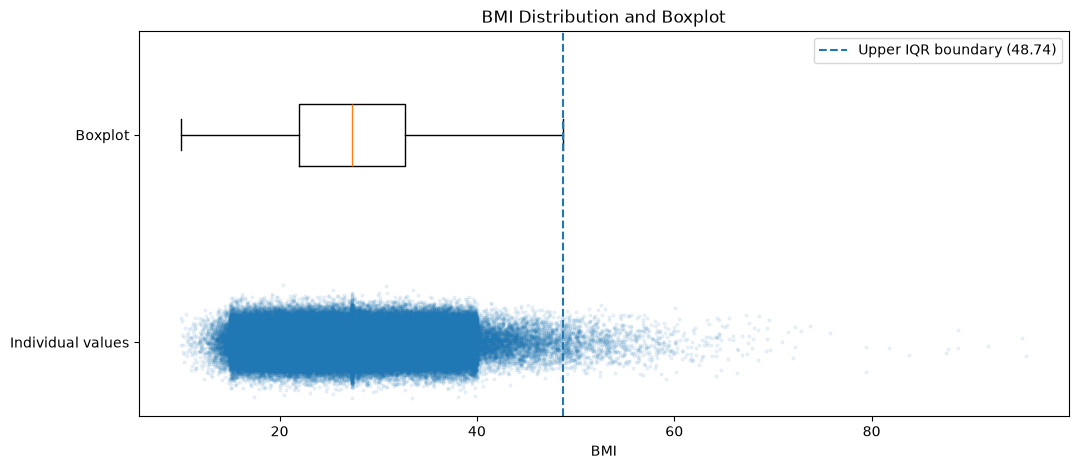

In [16]:
import numpy as np

# Set a random seed so the jitter is reproducible
np.random.seed(42)

# Create small vertical offsets for the individual observations
jitter = np.random.normal(
    loc=0,
    scale=0.06,
    size=len(df_clean)
)

# Create the figure
plt.figure(figsize=(12, 5))

# Plot all BMI observations with vertical jitter
plt.scatter(
    df_clean["bmi"],
    jitter,
    s=4,
    alpha=0.08
)

# Plot the boxplot above the individual observations
plt.boxplot(
    df_clean["bmi"].dropna(),
    vert=False,
    positions=[1],
    widths=0.3,
    showfliers=False
)

# Show the upper IQR boundary used for potential outlier detection
plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper IQR boundary ({upper_bound:.2f})"
)

# Label the graph
plt.yticks(
    [0, 1],
    ["Individual values", "Boxplot"]
)

plt.xlabel("BMI")
plt.title("BMI Distribution and Boxplot")
plt.legend()

plt.show()

In [17]:
# Select numerical columns for outlier checking
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Count potential outliers in each numerical column using the IQR method
for column in numerical_columns:
    outlier_flag = iqr_flag(df_clean[column])

    print(
        f"{column}: {outlier_flag.sum()} potential outliers"
    )

age: 0 potential outliers
age_normalized: 0 potential outliers
bmi: 1005 potential outliers
hypertension: 8060 potential outliers
heart_disease: 10051 potential outliers
HbA1c_level: 0 potential outliers
glucose: 2028 potential outliers
cholesterol: 0 potential outliers
sleep_hours: 1526 potential outliers
triglycerides: 0 potential outliers
blood_pressure: 30308 potential outliers
crp_level: 30295 potential outliers
homocysteine_level: 30989 potential outliers
systolic_bp: 27371 potential outliers
diastolic_bp: 23230 potential outliers
alcohol_intake: 32706 potential outliers
salt_intake: 33549 potential outliers
heart_rate: 20939 potential outliers
hdl: 24946 potential outliers
ldl: 29273 potential outliers


In [18]:
# Create a summary of IQR outliers for each numerical column
outlier_summary = []

for column in numerical_columns:
    # Calculate quartiles and IQR
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    # Calculate the lower and upper IQR boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Flag potential outliers
    outlier_flag = iqr_flag(df_clean[column])
    outlier_count = outlier_flag.sum()

    # Store the results
    outlier_summary.append({
        "Column": column,
        "Min": df_clean[column].min(),
        "Lower Bound": lower_bound,
        "Q1": q1,
        "Q3": q3,
        "Upper Bound": upper_bound,
        "Max": df_clean[column].max(),
        "Outliers": outlier_count,
        "Outlier %": (outlier_count / len(df_clean)) * 100
    })

# Convert the results into a dataframe
outlier_summary_df = pd.DataFrame(outlier_summary)

# Display the summary rounded for readability
outlier_summary_df.round(2)

,Column,Min,Lower Bound,Q1,Q3,Upper Bound,Max,Outliers,Outlier %
0,age,2.00,-22.00,32.00,68.00,122.00,89.00,0,0.00
1,age_normalized,0.00,-0.28,0.34,0.76,1.38,1.00,0,0.00
2,bmi,10.01,5.97,22.01,32.70,48.74,95.69,1005,0.36
3,hypertension,0.00,-0.33,0.00,0.22,0.54,1.00,8060,2.89
4,heart_disease,0.00,-0.18,0.00,0.12,0.29,1.00,10051,3.61
5,HbA1c_level,3.50,3.17,5.39,6.87,9.08,9.00,0,0.00
6,glucose,70.00,10.00,100.00,160.00,250.00,300.00,2028,0.73
7,cholesterol,150.00,138.00,201.00,243.00,306.00,300.00,0,0.00
8,sleep_hours,4.00,3.94,6.20,7.70,9.95,10.00,1526,0.55
9,triglycerides,50.00,-42.62,128.00,241.75,412.38,400.00,0,0.00


In [19]:
# Check whether potential outliers fall below or above the IQR boundaries
outlier_direction_summary = []

for column in numerical_columns:
    # Calculate the quartiles and IQR
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    # Calculate the lower and upper IQR boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count values below and above the boundaries
    lower_outliers = (df_clean[column] < lower_bound).sum()
    upper_outliers = (df_clean[column] > upper_bound).sum()

    # Store the results
    outlier_direction_summary.append({
        "Column": column,
        "Lower Outliers": lower_outliers,
        "Upper Outliers": upper_outliers,
        "Total Outliers": lower_outliers + upper_outliers
    })

# Convert the results into a dataframe
outlier_direction_df = pd.DataFrame(outlier_direction_summary)

# Display the results
outlier_direction_df

,Column,Lower Outliers,Upper Outliers,Total Outliers
0,age,0,0,0
1,age_normalized,0,0,0
2,bmi,0,1005,1005
3,hypertension,0,8060,8060
4,heart_disease,0,10051,10051
5,HbA1c_level,0,0,0
6,glucose,0,2028,2028
7,cholesterol,0,0,0
8,sleep_hours,0,1526,1526
9,triglycerides,0,0,0


C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


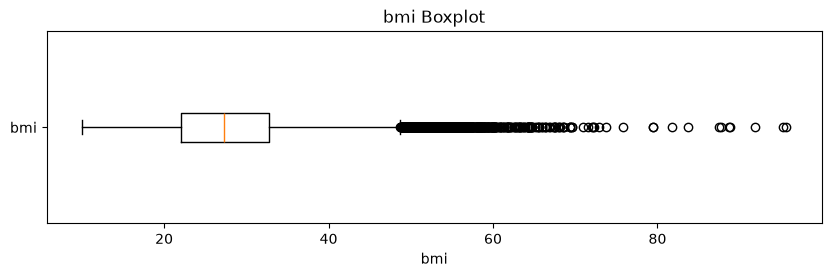

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


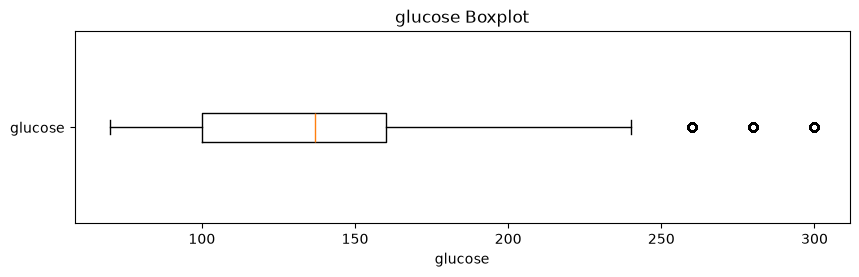

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


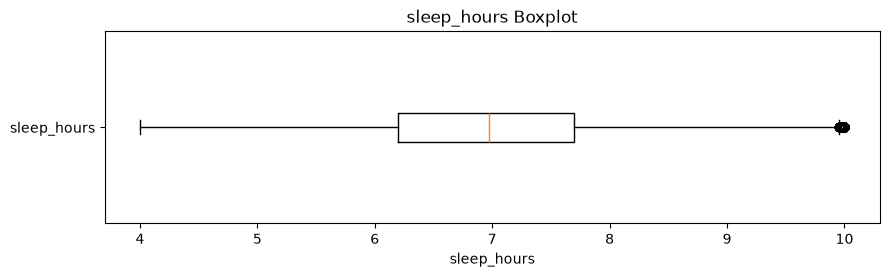

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


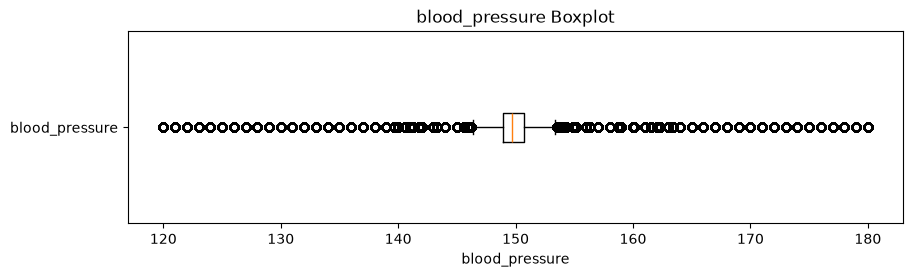

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


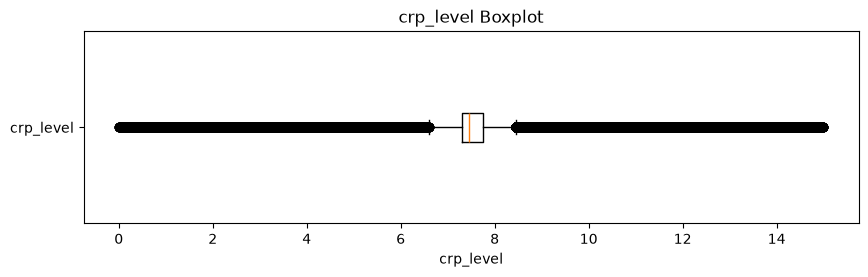

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


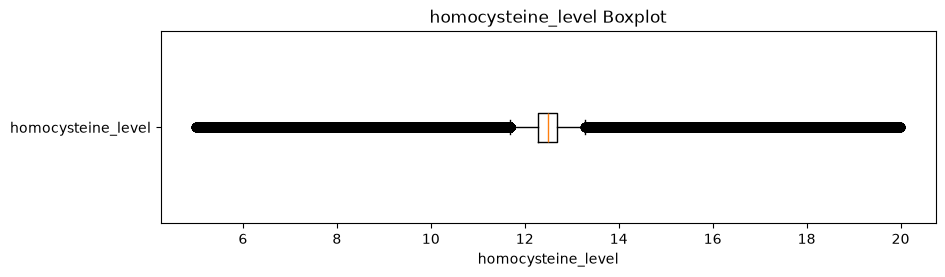

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


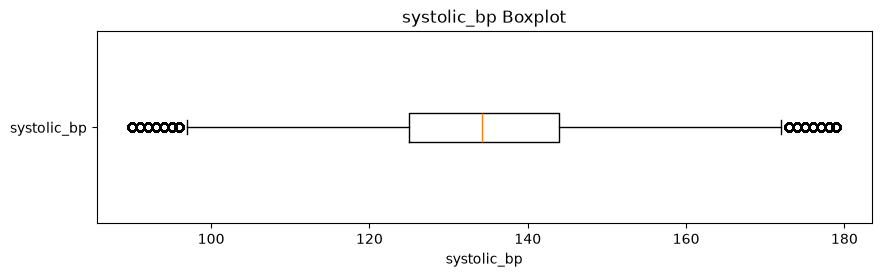

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


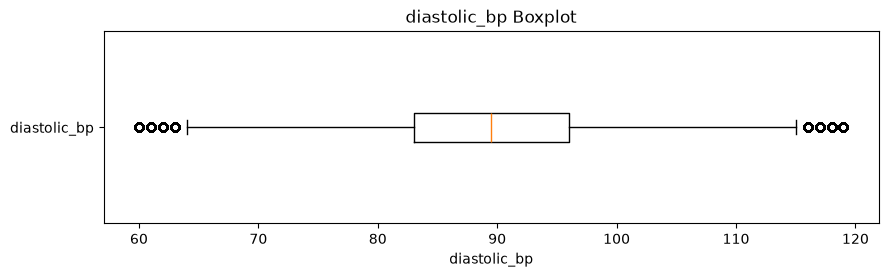

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


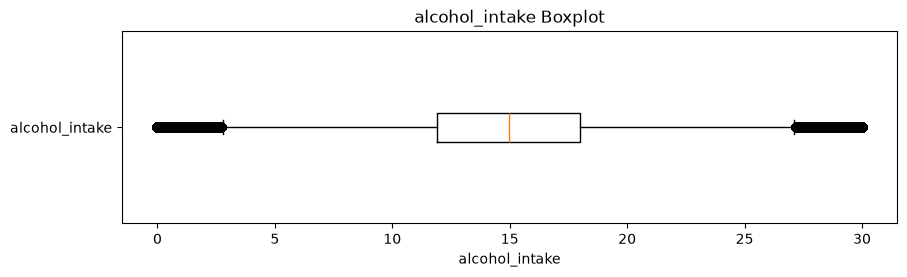

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


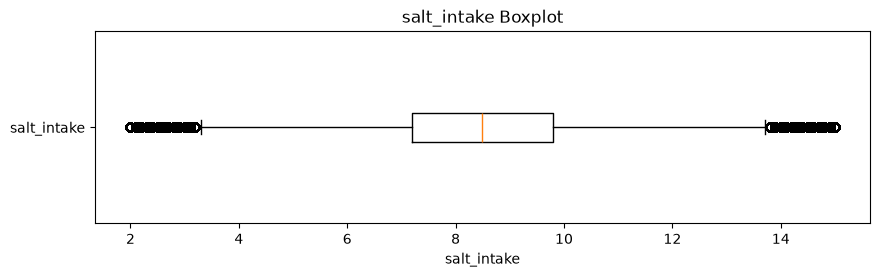

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


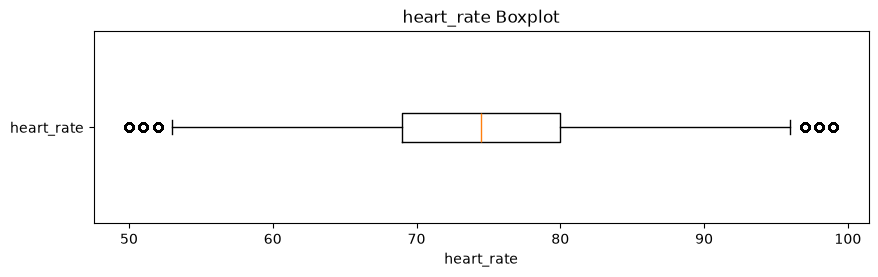

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


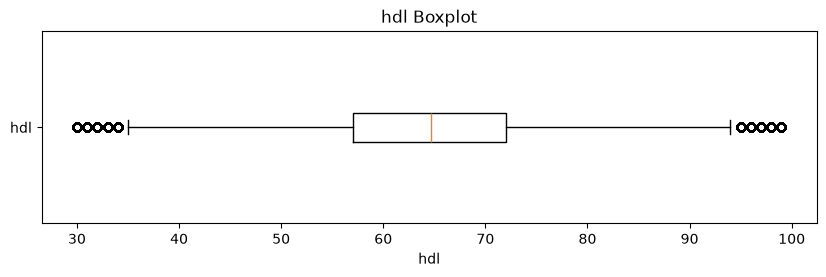

C:\Users\leoca\AppData\Local\Temp\ipykernel_16972\3326683802.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


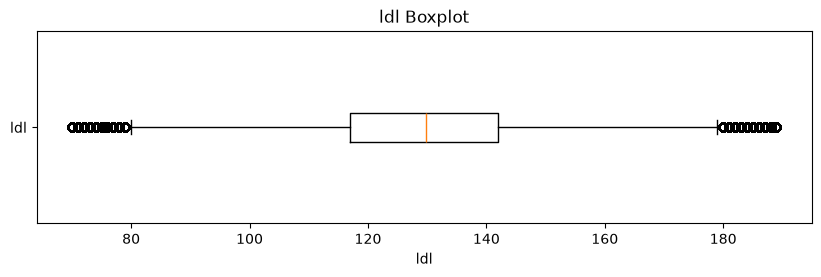

In [20]:
# Select numerical variables that had potential IQR outliers
outlier_columns = [
    "bmi",
    "glucose",
    "sleep_hours",
    "blood_pressure",
    "crp_level",
    "homocysteine_level",
    "systolic_bp",
    "diastolic_bp",
    "alcohol_intake",
    "salt_intake",
    "heart_rate",
    "hdl",
    "ldl"
]

# Create a boxplot for each variable with potential outliers
for column in outlier_columns:
    plt.figure(figsize=(10, 2.5))

    plt.boxplot(
        df_clean[column].dropna(),
        vert=False,
        tick_labels=[column]
    )

    plt.xlabel(column)
    plt.title(f"{column} Boxplot")

    plt.show()

In [21]:
# Inspect the values flagged as glucose outliers
glucose_flag = iqr_flag(df_clean["glucose"])

print("Glucose outlier values:")
print(
    df_clean.loc[glucose_flag, "glucose"]
    .value_counts()
    .sort_index()
)

# Inspect the values flagged as sleep-hour outliers
sleep_flag = iqr_flag(df_clean["sleep_hours"])

print("\nSleep hour outlier values:")
print(
    df_clean.loc[sleep_flag, "sleep_hours"]
    .value_counts()
    .sort_index()
)

Glucose outlier values:
glucose
260.0    634
280.0    722
300.0    672
Name: count, dtype: int64

Sleep hour outlier values:
sleep_hours
9.955178        1
9.955651        1
9.955790        1
9.956228        1
9.956338        1
             ... 
9.998525        1
9.998776        1
9.999151        1
9.999952        1
10.000000    1462
Name: count, Length: 65, dtype: int64


## 3.3 Validation of the Cleaned Dataset

In [22]:
# Compare the original and cleaned dataset dimensions
print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)

# Check for any remaining duplicate rows
print("Remaining duplicate rows:", df_clean.duplicated().sum())

# Check for missing values in the cleaned dataset
print("Total missing values:", df_clean.isnull().sum().sum())

# Display the data types after cleaning
print("\nCleaned data types:")
print(df_clean.dtypes)

Original shape: (280985, 39)
Cleaned shape: (278701, 40)
Remaining duplicate rows: 0
Total missing values: 0

Cleaned data types:
composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diasto

In [23]:
# Check the relationship between sublabel and the new heart disease target
target_mapping_check = pd.crosstab(
    df_clean["sublabel"],
    df_clean["heart_disease_target"]
)

print(target_mapping_check)

heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0


In [24]:
# Compare numerical ranges before and after cleaning
numerical_columns = df_original.select_dtypes(
    include=["int64", "float64"]
).columns

range_comparison = []

for column in numerical_columns:
    # Store the minimum and maximum values before and after cleaning
    range_comparison.append({
        "Column": column,
        "Original Min": df_original[column].min(),
        "Cleaned Min": df_clean[column].min(),
        "Original Max": df_original[column].max(),
        "Cleaned Max": df_clean[column].max()
    })

# Convert the results into a dataframe
range_comparison_df = pd.DataFrame(range_comparison)

# Display the comparison
range_comparison_df

,Column,Original Min,Cleaned Min,Original Max,Cleaned Max
0,age,2.000000,2.000000,89.000000,89.000000
1,age_normalized,0.000000,0.000000,1.000000,1.000000
2,bmi,10.010000,10.010000,95.690000,95.690000
3,hypertension,0.000000,0.000000,1.000000,1.000000
4,heart_disease,0.000000,0.000000,1.000000,1.000000
5,HbA1c_level,3.500000,3.500000,9.000000,9.000000
6,glucose,70.000000,70.000000,300.000000,300.000000
7,cholesterol,150.000000,150.000000,300.000000,300.000000
8,sleep_hours,4.000000,4.000000,10.000000,10.000000
9,triglycerides,50.000000,50.000000,400.000000,400.000000


In [25]:
# Save the cleaned dataset for the exploratory analysis notebook
cleaned_data_path = "../data/patient_data_cleaned.csv"
df_clean.to_csv(cleaned_data_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_data_path}")
print(f"Saved shape: {df_clean.shape}")

Cleaned dataset saved to: ../data/patient_data_cleaned.csv
Saved shape: (278701, 40)


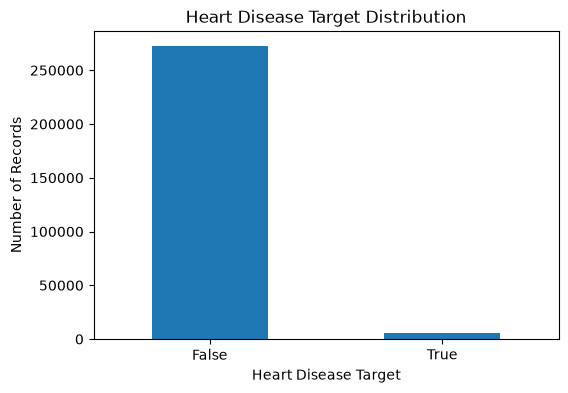

In [26]:
# Count the heart disease target classes
target_counts = df_clean["heart_disease_target"].value_counts()

# Plot the target class distribution
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.xlabel("Heart Disease Target")
plt.ylabel("Number of Records")
plt.title("Heart Disease Target Distribution")
plt.xticks(rotation=0)

plt.show()

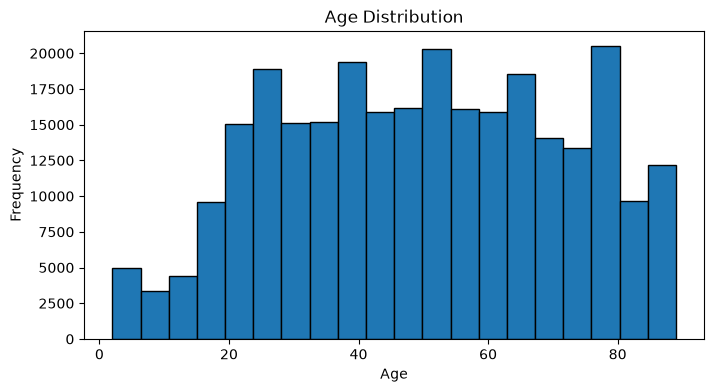

In [27]:
# Plot the distribution of patient ages
plt.figure(figsize=(8, 4))

plt.hist(
    df_clean["age"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

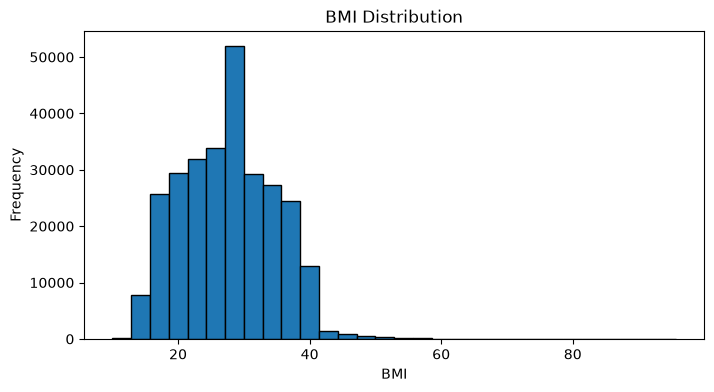

In [28]:
# Plot the distribution of BMI values
plt.figure(figsize=(8, 4))

plt.hist(
    df_clean["bmi"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("BMI Distribution")

plt.show()

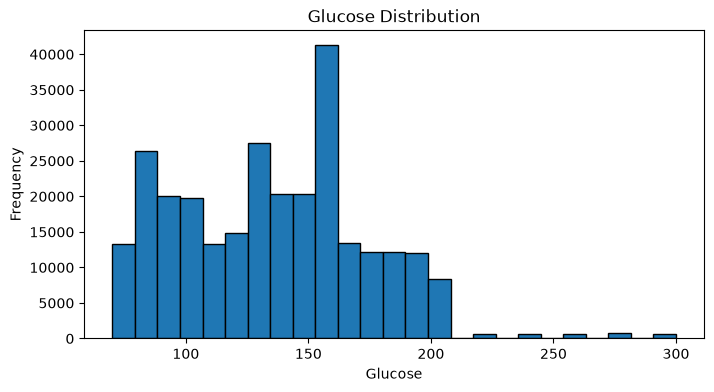

In [29]:
# Plot the distribution of glucose values
plt.figure(figsize=(8, 4))

plt.hist(
    df_clean["glucose"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Glucose Distribution")

plt.show()

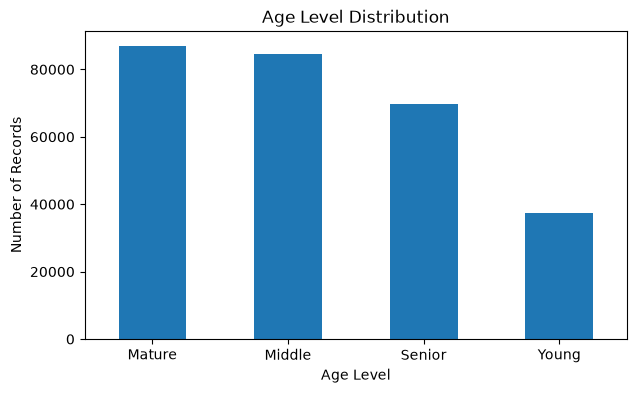

In [30]:
# Count records in each age group
age_level_counts = df_clean["age_level"].value_counts()

# Plot the age group distribution
plt.figure(figsize=(7, 4))

age_level_counts.plot(kind="bar")

plt.xlabel("Age Level")
plt.ylabel("Number of Records")
plt.title("Age Level Distribution")
plt.xticks(rotation=0)

plt.show()

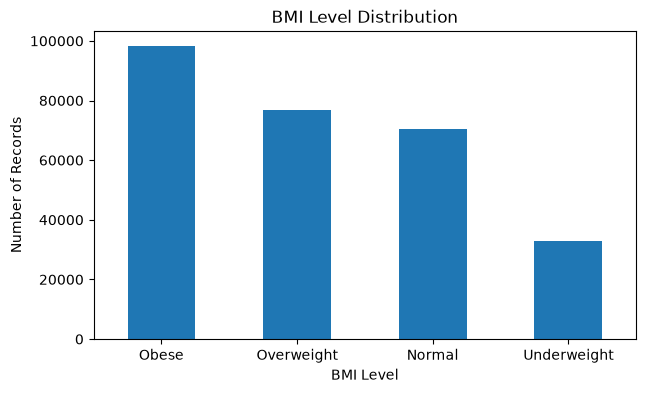

In [31]:
# Count records in each BMI category
bmi_level_counts = df_clean["bmi_level"].value_counts()

# Plot the BMI category distribution
plt.figure(figsize=(7, 4))

bmi_level_counts.plot(kind="bar")

plt.xlabel("BMI Level")
plt.ylabel("Number of Records")
plt.title("BMI Level Distribution")
plt.xticks(rotation=0)

plt.show()

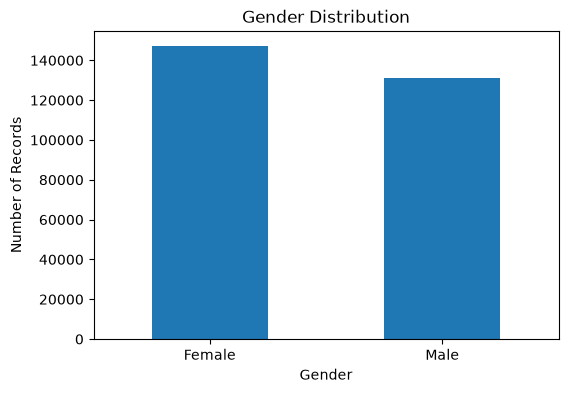

In [32]:
# Count records for each gender
gender_counts = df_clean["gender"].value_counts()

# Plot the gender distribution
plt.figure(figsize=(6, 4))

gender_counts.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.title("Gender Distribution")
plt.xticks(rotation=0)

plt.show()

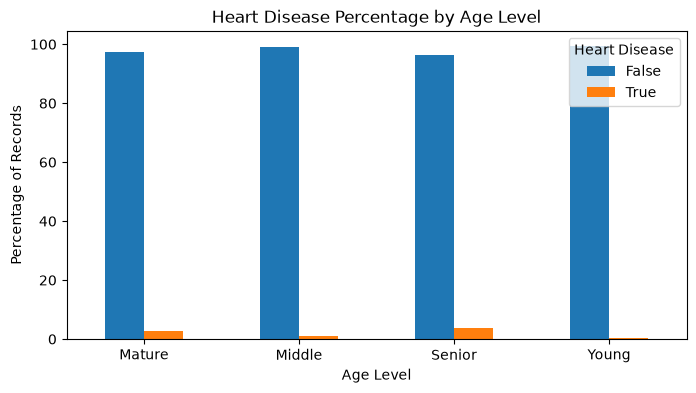

In [33]:
# Calculate the percentage of each target class within each age level
age_target_percentage = pd.crosstab(
    df_clean["age_level"],
    df_clean["heart_disease_target"],
    normalize="index"
) * 100

# Plot the percentage distribution
age_target_percentage.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.xlabel("Age Level")
plt.ylabel("Percentage of Records")
plt.title("Heart Disease Percentage by Age Level")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease")

plt.show()

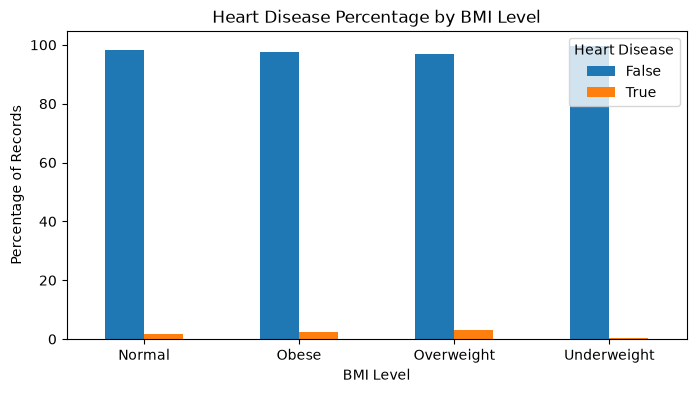

In [34]:
# Calculate the percentage of each target class within each BMI level
bmi_target_percentage = pd.crosstab(
    df_clean["bmi_level"],
    df_clean["heart_disease_target"],
    normalize="index"
) * 100

# Plot the percentage distribution
bmi_target_percentage.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.xlabel("BMI Level")
plt.ylabel("Percentage of Records")
plt.title("Heart Disease Percentage by BMI Level")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease")

plt.show()

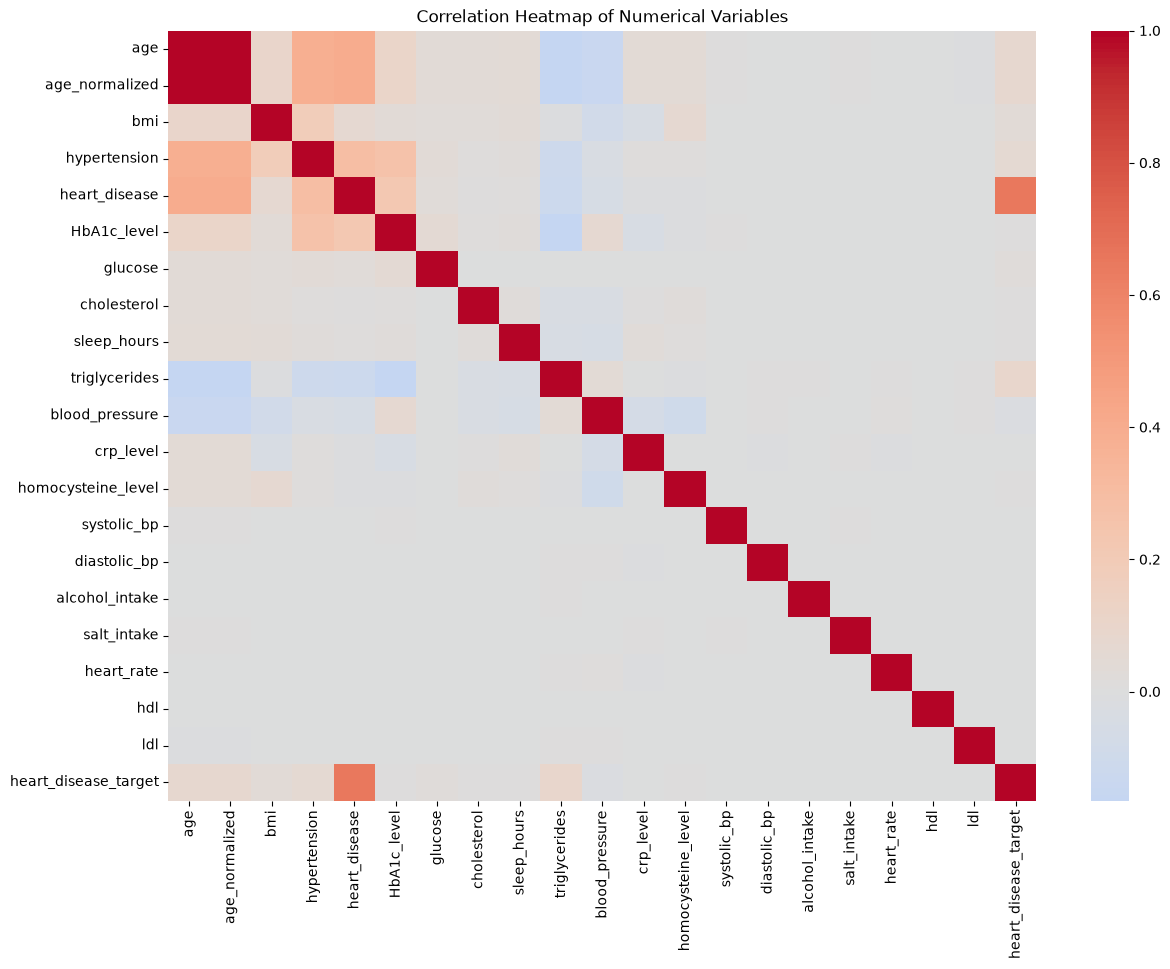

In [35]:
import seaborn as sns

# Select numerical columns for correlation analysis
correlation_data = df_clean.select_dtypes(
    include=["int64", "float64", "bool"]
)

# Calculate correlations between numerical variables
correlation_matrix = correlation_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()